In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("hospital_bigdata_patients.csv")
print("Ukuran data:", df.shape)
df.head()

Saving hospital_bigdata_patients.csv to hospital_bigdata_patients.csv
Ukuran data: (50000, 10)


,admission_date,patient_id,age,gender,diagnosis,comorbidity_score,heart_rate,blood_pressure,lab_result,length_of_stay
0,2024-09-12 14:00:00,210398,40,Female,Cardiac,0,101.372684,132.039015,48.920923,3.705525
1,2023-10-21 03:00:00,790381,67,Male,Infection,1,81.196332,127.161679,67.861882,3.444815
2,2022-02-05 20:00:00,326544,49,Male,Infection,0,86.059811,105.084661,54.224392,1.432453
3,2022-08-13 14:00:00,327368,26,Female,Cardiac,0,69.553945,110.530036,37.406681,2.571625
4,2024-06-17 23:00:00,229611,52,Female,Hypertension,1,83.046681,110.623687,49.664117,5.659547


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   admission_date     50000 non-null  object 
 1   patient_id         50000 non-null  int64  
 2   age                50000 non-null  int64  
 3   gender             50000 non-null  object 
 4   diagnosis          50000 non-null  object 
 5   comorbidity_score  50000 non-null  int64  
 6   heart_rate         50000 non-null  float64
 7   blood_pressure     50000 non-null  float64
 8   lab_result         50000 non-null  float64
 9   length_of_stay     50000 non-null  float64
dtypes: float64(4), int64(3), object(3)
memory usage: 3.8+ MB


In [4]:
df['admission_date'] = pd.to_datetime(df['admission_date'])
df = df.dropna()
df = df.drop_duplicates()
df.head()

,admission_date,patient_id,age,gender,diagnosis,comorbidity_score,heart_rate,blood_pressure,lab_result,length_of_stay
0,2024-09-12 14:00:00,210398,40,Female,Cardiac,0,101.372684,132.039015,48.920923,3.705525
1,2023-10-21 03:00:00,790381,67,Male,Infection,1,81.196332,127.161679,67.861882,3.444815
2,2022-02-05 20:00:00,326544,49,Male,Infection,0,86.059811,105.084661,54.224392,1.432453
3,2022-08-13 14:00:00,327368,26,Female,Cardiac,0,69.553945,110.530036,37.406681,2.571625
4,2024-06-17 23:00:00,229611,52,Female,Hypertension,1,83.046681,110.623687,49.664117,5.659547


In [5]:
df_monthly = df.resample('M', on='admission_date').mean(numeric_only=True)
df_monthly.head()

/tmp/ipython-input-2881573245.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M', on='admission_date').mean(numeric_only=True)


,patient_id,age,comorbidity_score,heart_rate,blood_pressure,lab_result,length_of_stay
admission_date,,,,,,,
2022-01-31,555948.000000,45.184076,1.932798,79.833413,120.456644,49.908941,6.284763
2022-02-28,550938.431388,44.055994,1.992114,80.404271,119.796963,50.047353,6.507669
2022-03-31,547780.330703,43.925395,1.993544,79.618368,120.467665,50.116130,6.437536
2022-04-30,543868.581481,44.511111,2.046667,80.046583,119.976459,49.963083,6.460624
2022-05-31,544045.654070,43.486919,2.020349,79.821689,119.941267,49.425642,6.394411


In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_monthly)

,patient_id,age,comorbidity_score,heart_rate,blood_pressure,lab_result,length_of_stay
admission_date,,,,,,,
2022-01-31,555948.000000,45.184076,1.932798,79.833413,120.456644,49.908941,6.284763
2022-02-28,550938.431388,44.055994,1.992114,80.404271,119.796963,50.047353,6.507669
2022-03-31,547780.330703,43.925395,1.993544,79.618368,120.467665,50.116130,6.437536
2022-04-30,543868.581481,44.511111,2.046667,80.046583,119.976459,49.963083,6.460624
2022-05-31,544045.654070,43.486919,2.020349,79.821689,119.941267,49.425642,6.394411
2022-06-30,537132.996364,44.799273,2.074182,79.686252,119.483504,50.293920,6.488629
2022-07-31,552801.570544,46.057123,1.926359,80.087313,119.899930,50.290870,6.257420
2022-08-31,561713.986034,45.569832,1.983939,80.259821,120.434865,49.229182,6.427971
2022-09-30,551054.944401,45.653876,2.029757,80.365482,119.559561,49.980418,6.521911


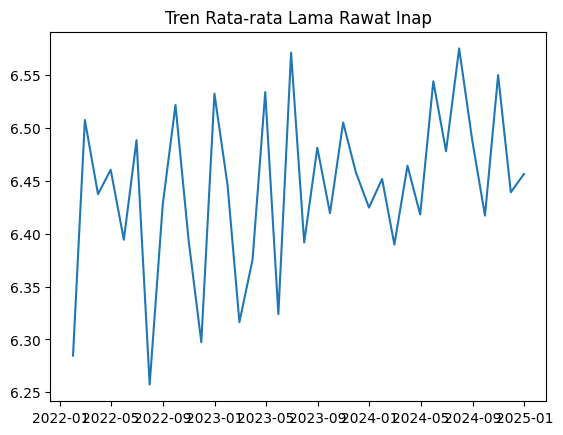

In [7]:
plt.figure()
plt.plot(df_monthly.index, df_monthly['length_of_stay'])
plt.title("Tren Rata-rata Lama Rawat Inap")
plt.show()

In [8]:
gender_counts = df['gender'].value_counts()
print("Jumlah Pasien berdasarkan Jenis Kelamin:")
print(gender_counts)

Jumlah Pasien berdasarkan Jenis Kelamin:
gender
Female    25045
Male      24955
Name: count, dtype: int64


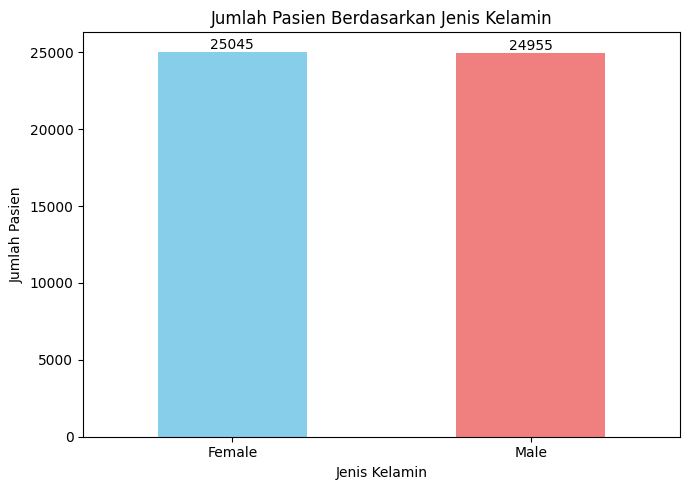

In [9]:
import matplotlib.pyplot as plt

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 5))
ax = gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Jumlah Pasien Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Pasien')
plt.xticks(rotation=0)

# Add labels to the bars
for index, value in enumerate(gender_counts):
    ax.text(index, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Dari grafik menunjukan jumlah pasien Female (25.045) dan Male (24.955) yang mana ini seimbang dan hanya selisih sedikit dan menunjukan ahwa dataset kita tidak memiliki kecondongan pada gender tertenu. Untuk tahap Feature Engineering, Karena jumlahnya seimbang, korelasi antara gender dengan length_of_stay dengan tingkat kepercayaan yang tinggi. Saya bisa membandingkan secara adil apakah rata-rata lama rawat inap pria memang berbeda signifikan dengan wanita tanpa khawatir kekurangan sampel data dari salah satu kelompok

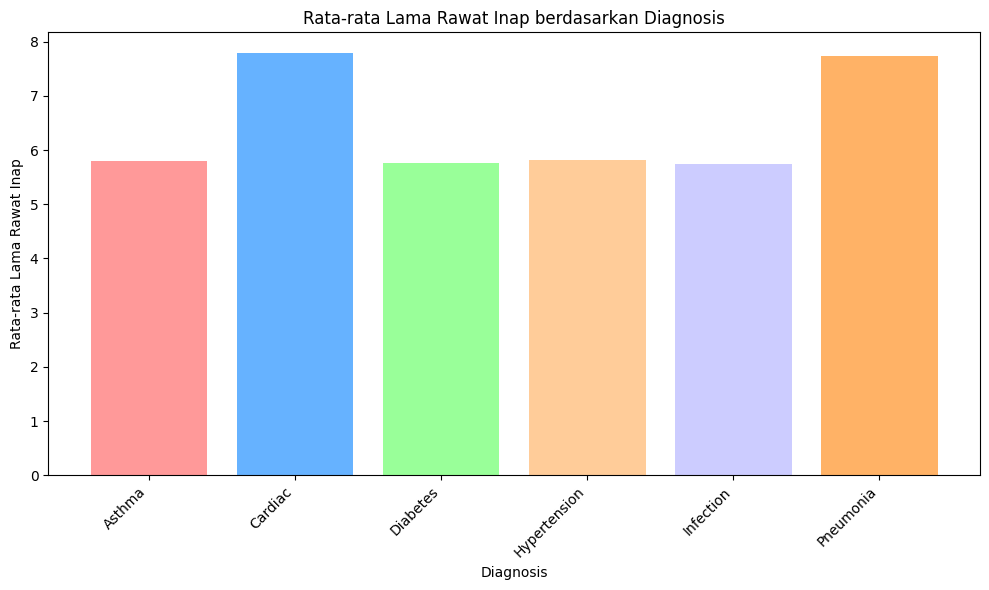

In [10]:
import matplotlib.pyplot as plt

df_diagnosis = df.groupby('diagnosis')['length_of_stay'].mean().reset_index()

plt.figure(figsize=(10, 6))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#CCCCFF', '#FFB266'] # Example colors
plt.bar(df_diagnosis['diagnosis'], df_diagnosis['length_of_stay'], color=colors[:len(df_diagnosis)])
plt.title('Rata-rata Lama Rawat Inap berdasarkan Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Rata-rata Lama Rawat Inap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dari grafik ini menjelaskan lama rawat inap berdasarkan diagnosis hasilnya yaitu Diagnosis Cardiac (Jantung) dan Pneumonia memiliki rata-rata rawat inap tertinggi dan Penyakit seperti Asthma, Diabetes, Hypertension (Darah Tinggi), dan Infection memiliki rata-rata yang lebih rendah. Sehingga walaupun jumlah pasien pria dan Wanita, namun lamanya mereka menginap di rumah sakit sangat bergantung pada jenis penyakitnya. Jadi, variabel 'Diagnosis' memiliki pengaruh yang lebih kuat terhadap Length of Stay dibandingkan variabel 'Gender'

In [11]:
df[['age','comorbidity_score','heart_rate','blood_pressure','lab_result','length_of_stay']].corr()

,age,comorbidity_score,heart_rate,blood_pressure,lab_result,length_of_stay
age,1.000000,0.003685,-0.008700,-0.005180,-0.006398,0.161251
comorbidity_score,0.003685,1.000000,0.010857,-0.011716,0.004902,0.759906
heart_rate,-0.008700,0.010857,1.000000,0.001454,0.002167,0.006028
blood_pressure,-0.005180,-0.011716,0.001454,1.000000,-0.000673,-0.011536
lab_result,-0.006398,0.004902,0.002167,-0.000673,1.000000,0.002437
length_of_stay,0.161251,0.759906,0.006028,-0.011536,0.002437,1.000000


In [12]:
X = df[['age','comorbidity_score','heart_rate','blood_pressure','lab_result']]
y = df['length_of_stay']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [13]:
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1.720788026018747
R2 Score: 0.605699085116401


In [ ]:
import pandas as pd

new_patient_data = pd.DataFrame({
    'age': [60],
    'comorbidity_score': [3],
    'heart_rate': [85.5],
    'blood_pressure': [130.0],
    'lab_result': [55.2]
})

predicted_los_new_patient = model.predict(new_patient_data)

print(f"Prediksi Lama Rawat Inap untuk pasien baru ini adalah: {predicted_los_new_patient[0]:.2f} hari")

Prediksi Lama Rawat Inap untuk pasien baru ini adalah: 8.18 hari


##INSIGHT##
• Dataset yang Seimbang karena 25.045 pasien perempuan dan 24.955 pasien laki
laki, sehingga data prediksi tidak condong ke gender tertentu
• jenis diagnosis merupakan faktor pembeda yang krusial, di mana penyakit Cardiac
	dan Pneumonia rata-rata membutuhkan waktu pemulihan terlama, yakni hampir 8 hari.
• Dari hasil analisis korelasi, ditemukan bahwa comorbidity_score (skor penyakit penyerta) merupakan prediktor utama yang paling menentukan dengan nilai korelasi positif yang sangat kuat sebesar 0,76. Hal ini menunjukkan bahwa tingkat kompleksitas penyakit pasien jauh lebih berpengaruh terhadap durasi rawat inap dibandingkan variabel klinis lain seperti tekanan darah atau detak jantung.
• Dari hasil Moodel menunjukkan performa yang solid dengan nilai R2 Score 0,605, yang berarti variabel input yang digunakan mampu menjelaskan 60,5% variasi data. Dengan nilai RMSE sebesar 1,72, rata-rata melesetnya prediksi model hanya sekitar 1,7 hari dari kenyataan. Keberhasilan model ini juga dibuktikan pada simulasi pasien baru yang diprediksi akan dirawat selama 8,18 hari, sehingga model ini sangat layak diaplikasikan sebagai sistem pendukung keputusan bagi manajemen rumah sakit dalam mengoptimalkan alokasi tempat tidur.
